#Predicts Stock Price

This project is very very non linear and has the use of svm in it,
But its only use is in educational purposes and not the purpose of in real life stock exchange

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
%matplotlib inline

In [92]:
stocks=input("Enter the code of the stock:")
data=yf.download(stocks,"2008-01-01","2025-04-18", auto_adjust=True) #takes in dates to which the records are shown
data=data.sort_values(by="Date",ascending=False)

Enter the code of the stock:TCS.NS


[*********************100%***********************]  1 of 1 completed


In [93]:
data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-04-17,3188.701172,3193.244359,3110.503706,3137.085077,2932346
2025-04-16,3164.439697,3168.596104,3121.136181,3139.694764,2384391
2025-04-15,3139.694580,3203.683137,3130.415407,3203.683137,3512160
2025-04-11,3123.552979,3188.749790,3098.904796,3179.663888,7108961
2025-04-09,3138.148438,3160.766673,3104.752522,3151.632395,2990265
2025-04-08,3182.949707,3237.127417,3146.557491,3191.745818,5557558
2025-04-07,3164.681396,3181.451683,2953.963621,2996.445437,6623955
2025-04-04,3189.184326,3286.085502,3185.414699,3250.273336,5317367


In [94]:
data.shape
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,4262.000000,4262.000000,4262.000000,4262.000000,4.262000e+03
mean,1461.064264,1476.223458,1446.320098,1461.572457,3.095912e+06
std,1179.235420,1189.853678,1169.300316,1179.662288,2.631950e+06
min,76.933807,80.080447,70.754272,77.244137,0.000000e+00
25%,445.937752,450.024342,441.075426,445.783076,1.757332e+06
50%,1003.991211,1013.717332,995.946691,1005.419212,2.448419e+06
75%,2518.213684,2547.332803,2497.013370,2521.701106,3.659879e+06
max,4311.585449,4348.038052,4272.055967,4332.652506,8.806715e+07


#Remeber
Target Variable --> Close

Feature --> Other Variables

#Data Display

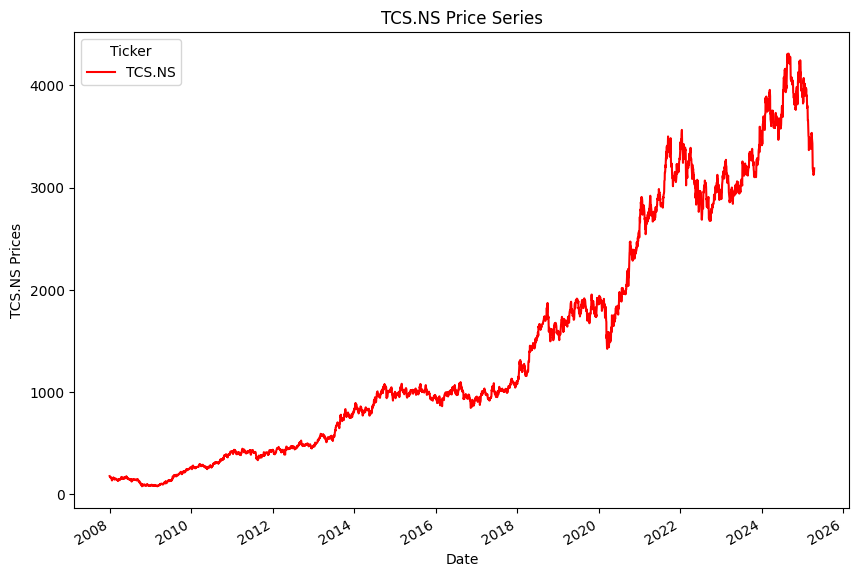

In [95]:
data.Close.plot(figsize=(10,7),color='r')
plt.ylabel("{} Prices".format(stocks)) #That {} adds the name of the plot to the side
plt.title("{} Price Series".format(stocks))
plt.show()

/tmp/ipykernel_11195/387798933.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Close"],color="r")


<Axes: ylabel='Density'>

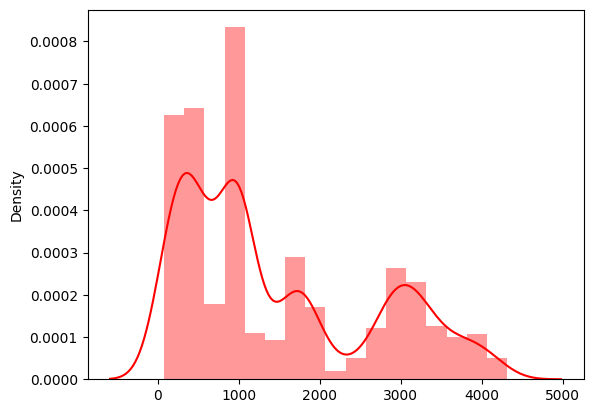

In [96]:
sns.distplot(data["Close"],color="r")

/tmp/ipykernel_11195/1726297072.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Open"],color="r")


<Axes: ylabel='Density'>

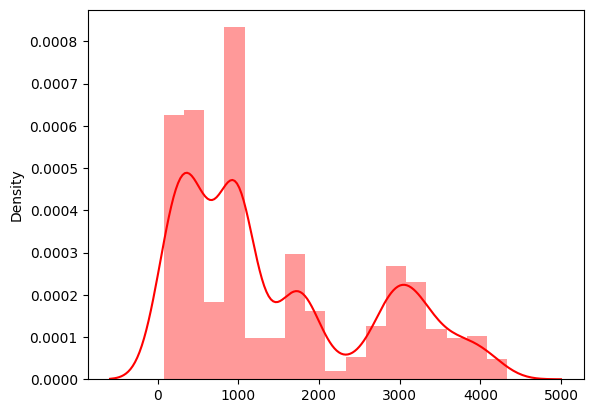

In [97]:
sns.distplot(data["Open"],color="r")

/tmp/ipykernel_11195/1593573666.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Volume"],color="g")


<Axes: ylabel='Density'>

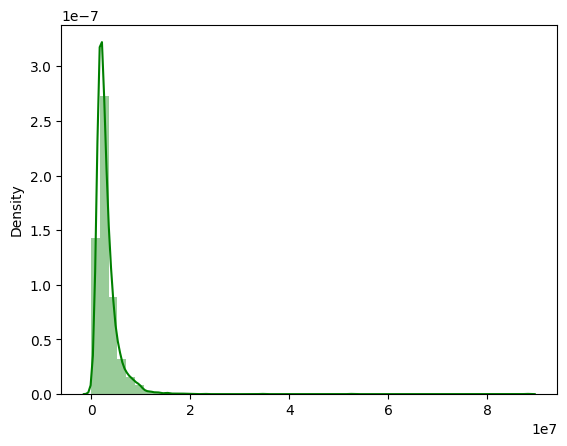

In [98]:
sns.distplot(data["Volume"],color="g")

bit more distributed

/tmp/ipykernel_11195/3886907153.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["High"],color="r")


<Axes: ylabel='Density'>

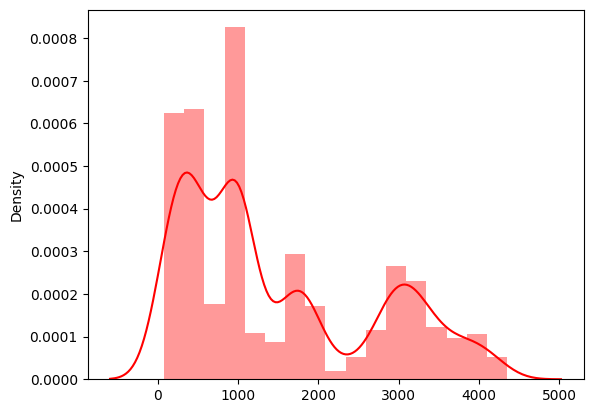

In [99]:
sns.distplot(data["High"],color="r")

/tmp/ipykernel_11195/3600518446.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Low"],color="r")


<Axes: ylabel='Density'>

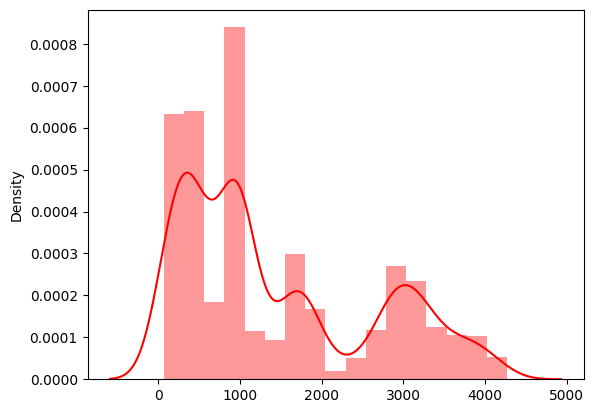

In [100]:
sns.distplot(data["Low"],color="r")

#WE SEE

--> Data is large

--> Highly non linear

--> Heavily Distributed

--> So very less dependence or Linear & Logistic Regression can be given and we would mainly focus upon our SVM and Regulaired Model

In [101]:
data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-04-17,3188.701172,3193.244359,3110.503706,3137.085077,2932346
2025-04-16,3164.439697,3168.596104,3121.136181,3139.694764,2384391
2025-04-15,3139.694580,3203.683137,3130.415407,3203.683137,3512160
2025-04-11,3123.552979,3188.749790,3098.904796,3179.663888,7108961
2025-04-09,3138.148438,3160.766673,3104.752522,3151.632395,2990265
2025-04-08,3182.949707,3237.127417,3146.557491,3191.745818,5557558
2025-04-07,3164.681396,3181.451683,2953.963621,2996.445437,6623955
2025-04-04,3189.184326,3286.085502,3185.414699,3250.273336,5317367


In [102]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data.drop("Close",axis=1),data["Close"],test_size=0.2,random_state=42)
#first part is the x and the y in the the right part of the code, i just shortened it down
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3409, 4)
(853, 4)
(3409, 1)
(853, 1)


In [103]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
pred=lr.predict(x_test)  #takes all the features in the test tab for testing
print(pred)

[[ 165.79946141]
 [1876.42436765]
 [1258.75859986]
 [ 182.94970415]
 [ 149.36740357]
 [ 416.06511424]
 [ 944.89747692]
 [1888.12612035]
 [ 505.44953387]
 [1000.21692774]
 [ 395.02575768]
 [ 444.93884701]
 [ 387.36499797]
 [ 392.5329092 ]
 [2904.13821167]
 [1089.2832721 ]
 [1421.8087386 ]
 [ 206.58581109]
 [ 498.85281178]
 [ 306.50380824]
 [ 245.80250936]
 [ 266.64183283]
 [ 276.32899989]
 [ 417.2746739 ]
 [ 181.66916675]
 [ 264.80353534]
 [1007.05820318]
 [ 920.01087212]
 [3123.08342608]
 [3042.08350498]
 [1030.41037594]
 [ 160.40740499]
 [1666.94526753]
 [1030.914276  ]
 [ 935.40435932]
 [4124.15428607]
 [1446.52083107]
 [1005.37279038]
 [  91.35826195]
 [ 675.45754682]
 [3831.75588344]
 [ 700.8135141 ]
 [ 503.32742629]
 [ 460.84645616]
 [2874.70280303]
 [1016.1630033 ]
 [3253.96293289]
 [4155.96802881]
 [ 336.02022961]
 [3084.91446064]
 [ 144.67118466]
 [1773.21921667]
 [1023.90336291]
 [ 403.57095508]
 [1892.19410457]
 [3222.56249307]
 [ 223.13777491]
 [ 964.35639546]
 [ 275.6747689

#MSE and RMSE

R2_Square= 1.0 --> Good Model

In [104]:
from sklearn.metrics import mean_squared_error,r2_score

#we have the mse function but need to code out the rmse
def calculate_metrics(y_test,pred):
  print("MSE:",mean_squared_error(y_test,pred)) #y_test is the ground truth
  print("RMSE:",np.sqrt(mean_squared_error(y_test,pred))) #pred is the model prediction (if you wrote moral prediction this is the one)
  print("R2_Score:",r2_score(y_test,pred))

calculate_metrics(y_test,pred)

MSE: 107.57677130150981
RMSE: 10.371922256819602
R2_Score: 0.9999294931518258


#The Regularization Models

In [105]:
from sklearn.linear_model import Lasso, Ridge
la=Lasso()
ri=Ridge()
la.fit(x_train,y_train)
ri.fit(x_train,y_train)
predla=la.predict(x_test)
predri=ri.predict(x_test)
def msers(y_test,predla,predri):
  print("Lasso MSE:",mean_squared_error(y_test,predla))
  print("Lasso RMSE:",np.sqrt(mean_squared_error(y_test,predla)))
  print("Lasso R2_Score:",r2_score(y_test,predla))
  print("\n")
  print("Ridge MSE:",mean_squared_error(y_test,predri))
  print("Ridge RMSE:",np.sqrt(mean_squared_error(y_test,predri)))
  print("Ridge R2_Score:",r2_score(y_test,predri))
msers(y_test,predla,predri)

Lasso MSE: 206.0078957107865
Lasso RMSE: 14.352975151890513
Lasso R2_Score: 0.9998649804483826


Ridge MSE: 107.57680053349898
Ridge RMSE: 10.371923666008104
Ridge R2_Score: 0.9999294931326668


#Support Vector Machine (SVM)

In [106]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV  #fine tunng of the model
svr=SVR()
param_grid={
    "C":[0.1,1,10,100,1000],               #width of the margin
    "gamma":[1,0.1,0.01,0.001,0.0001],     #for the 'reach' of decision boundary and is used for no linear data
    "kernel":['rbf']                       #for mapping data into infinite space
}
grid=GridSearchCV(svr,param_grid,refit=True,verbose=3)
grid.fit(x_train,y_train)
grid_predictions=grid.predict(x_test)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.137 total time=   0.9s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.132 total time=   0.7s


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 4/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-0.046 total time=   0.7s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-0.039 total time=   0.9s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [107]:
grid.best_estimator_

SVR(C=1000, gamma=0.0001)

based on whatever we get, we would put that inside our svr

In [108]:
svr=SVR(C=1000,gamma=0.0001,kernel='rbf')
svr.fit(x_train,y_train)
predsvr= svr.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [109]:
def meser(y_test,predsvr):
  print("SVR MSE:",mean_squared_error(y_test,predsvr))
  print("SVR RMSE:",np.sqrt(mean_squared_error(y_test,predsvr)))
  print("SVR R2_Score:",r2_score(y_test,predsvr))
meser(y_test,predsvr)

SVR MSE: 1650684.6366062488
SVR RMSE: 1284.7897246655768
SVR R2_Score: -0.08187455013484746


We see that **Regularised models** work way better here compared to SVR

Now this maybe so as there are very less amount of features present in the data and so the SVR cant learn enough

But we see the general models working better here

#Saving For Websites

In [110]:
import joblib
joblib.dump(ri,'model.pkl')
model=joblib.load('model.pkl')
#we then simply use this
#we saved our ridge model for this